# Statistic Analysis of UEs

This notebook visualizes metrics for UEs, including:

- Average throughput per UE

- Q queues stability (RLC queues)

- G queues stability (virtual queues)

- Allocated Resource Blocks (RBs)

The data comes from the ue_qos_stats.csv file generated by the gNB MAC scheduler.

## Imports

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# Force inline rendering to avoid blocking GUI event loops in VS Code notebooks.
%matplotlib inline
plt.ioff()

## Load data from file

In [56]:
# Load the CSV file
file_path = '../cmake_targets/ran_build/build/ue_qos_stats.csv'
df = pd.read_csv(file_path)

# Verify required columns from the new async logger format
required_cols = ['UID', 'Time', 'Throughput_Mbps', 'RLC_Q_Bytes', 'Virtual_Q_Bytes']
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print(len(df))
print(f"Columns: {list(df.columns)}")
print("\nFirst rows:")
df.head(10)

242751
Columns: ['Time', 'Frame', 'Slot', 'RNTI', 'UID', 'Throughput_Mbps', 'Coeff_UE', 'RLC_Q_Bytes', 'Virtual_Q_Bytes']

First rows:


,Time,Frame,Slot,RNTI,UID,Throughput_Mbps,Coeff_UE,RLC_Q_Bytes,Virtual_Q_Bytes
0,1776083949,301,9,39521,0,0.0,0.0,0,0
1,1776083949,302,0,39521,0,0.0,0.0,0,0
2,1776083949,302,1,39521,0,0.0,0.0,0,0
3,1776083949,302,2,39521,0,0.0,0.0,0,0
4,1776083949,302,3,39521,0,0.0,0.0,0,0
5,1776083949,302,4,39521,0,0.0,0.0,0,0
6,1776083949,302,5,39521,0,0.0,0.0,0,0
7,1776083949,302,6,39521,0,0.0,0.0,0,0
8,1776083949,302,7,39521,0,0.0,0.0,0,0
9,1776083949,302,8,39521,0,0.0,0.0,0,0


## MCS

In [57]:
df = pd.read_csv(file_path)
if 'MCS' not in df.columns:
    print("Column 'MCS' is not present in the new CSV format. Skipping MCS plot.")
else:
    for uid, group in df.groupby('UID'):
        unique_times = group.groupby('Time').agg({
            'MCS': 'mean'
        }).reset_index()
        if len(unique_times) > 0:
            mean_mcs = unique_times['MCS'].mean()
            print(f"UE {uid+1}: Mean MCS = {mean_mcs:.2f}")
            plt.plot(unique_times['Time'], unique_times['MCS'], label=f'UE {uid+1}')
    plt.xlabel('Time (sec.)')
    plt.ylabel('MCS')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Column 'MCS' is not present in the new CSV format. Skipping MCS plot.


## Average throughput per UE

UE 1: Average throughput = 0.00 Mbps


UE 2: Average throughput = 0.00 Mbps


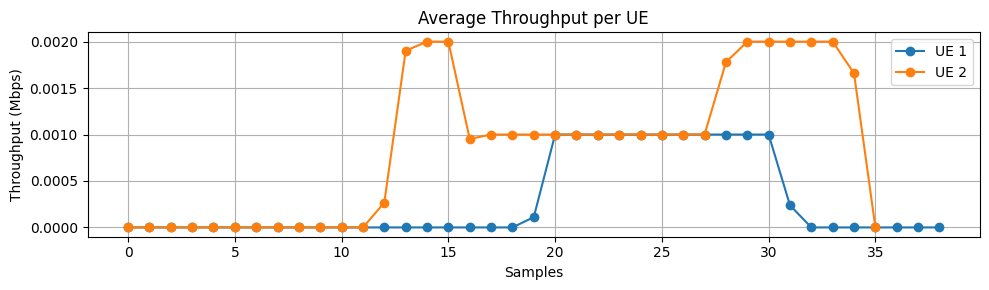

In [58]:
import numpy as np
plt.figure(figsize=(10, 3))
df = pd.read_csv(file_path)
for uid, group in df.groupby('UID'):
    unique_times = group.groupby('Time').agg({
        'Throughput_Mbps': 'mean'
    }).reset_index()
    x = range(len(unique_times))
    plt.plot(x, unique_times['Throughput_Mbps'], marker='o', label=f'UE {uid+1}')
    avg_throughput = unique_times['Throughput_Mbps'].mean()
    print(f"UE {uid+1}: Average throughput = {avg_throughput:.2f} Mbps")
plt.xlabel('Samples')
plt.ylabel('Throughput (Mbps)')
plt.title('Average Throughput per UE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3472836/377173967.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels)


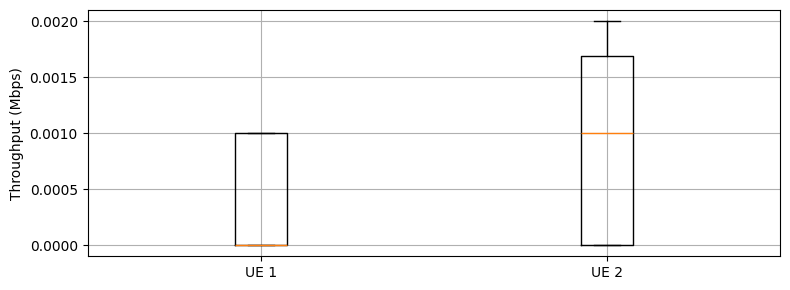

In [59]:
df = pd.read_csv(file_path)
plt.figure(figsize=(8, 3))
data_to_plot = []
labels = []
for uid, group in df.groupby('UID'):
    unique_times = group.groupby('Time').agg({
        'Throughput_Mbps': 'mean'
    }).reset_index()
    data_to_plot.append(unique_times['Throughput_Mbps'])
    labels.append(f'UE {uid+1}')
plt.boxplot(data_to_plot, labels=labels)
plt.ylabel('Throughput (Mbps)')
plt.grid(True)
plt.tight_layout()
plt.show()

## G stability

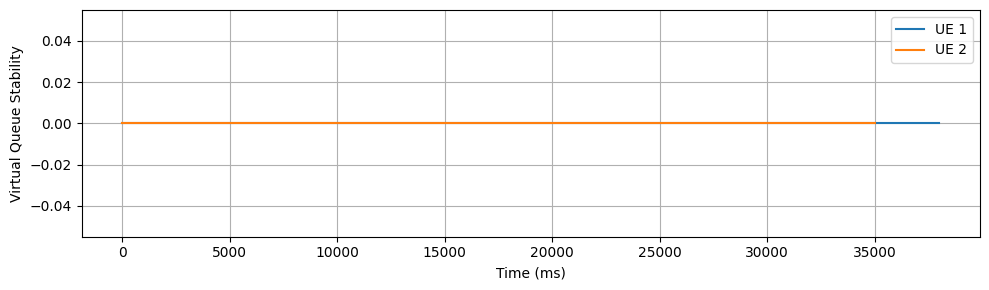

In [60]:
plt.figure(figsize=(10, 3))
df = pd.read_csv(file_path)
for uid, group in df.groupby('UID'):
    unique_times = group.groupby('Time').agg({
        'Virtual_Q_Bytes': 'mean'
    }).reset_index()
    if len(unique_times) > 0:
        start_time = unique_times['Time'].iloc[0]
        unique_times['Time_ms'] = (unique_times['Time'] - start_time) * 1000
        unique_times['Cumulative_bits'] = (unique_times['Virtual_Q_Bytes'] * 8).cumsum()
        unique_times['Stability'] = unique_times['Cumulative_bits'] / (unique_times['Time_ms'] + 1)
        plt.plot(unique_times['Time_ms'], unique_times['Stability'], label=f'UE {uid+1}')
plt.xlabel('Time (ms)')
plt.ylabel('Virtual Queue Stability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

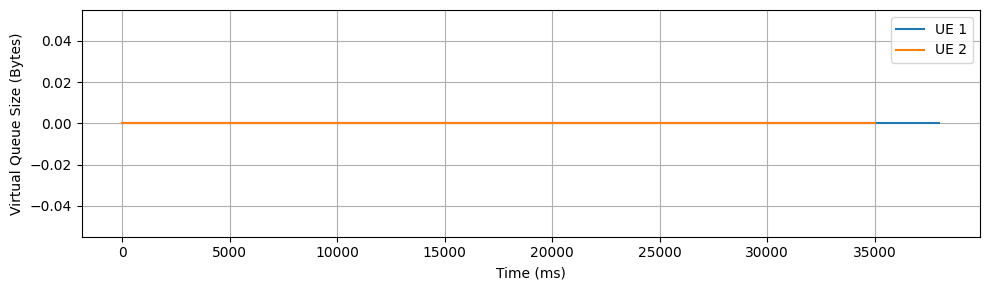

In [68]:
# Pintar la cola G (sin estabilidad)
plt.figure(figsize=(10, 3))
df = pd.read_csv(file_path)
for uid, group in df.groupby('UID'):
    unique_times = group.groupby('Time').agg({
        'Virtual_Q_Bytes': 'mean'
    }).reset_index()
    if len(unique_times) > 0:
        start_time = unique_times['Time'].iloc[0]
        unique_times['Time_ms'] = (unique_times['Time'] - start_time) * 1000
        plt.plot(unique_times['Time_ms'], unique_times['Virtual_Q_Bytes'], label=f'UE {uid+1}')
plt.xlabel('Time (ms)')
plt.ylabel('Virtual Queue Size (Bytes)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Q stability

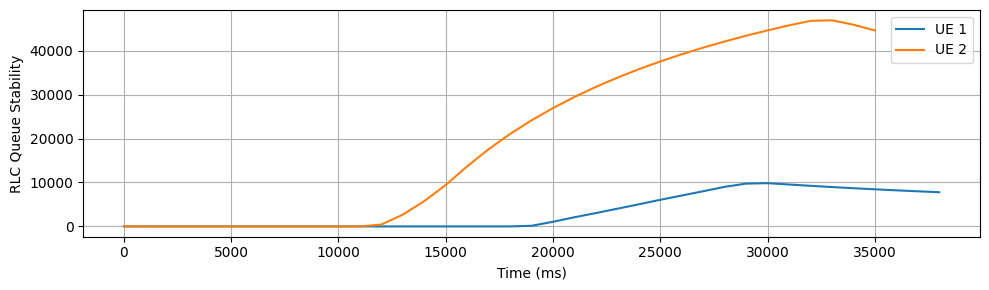

In [62]:
plt.figure(figsize=(10, 3))
df = pd.read_csv(file_path)
for uid, group in df.groupby('UID'):
    unique_times = group.groupby('Time').agg({
        'RLC_Q_Bytes': 'mean'
    }).reset_index()
    if len(unique_times) > 0:
        start_time = unique_times['Time'].iloc[0]
        unique_times['Time_ms'] = (unique_times['Time'] - start_time) * 1000
        unique_times['Cumulative_bits'] = (unique_times['RLC_Q_Bytes'] * 8).cumsum()
        unique_times['Stability'] = unique_times['Cumulative_bits'] / (unique_times['Time_ms'] + 1)
        plt.plot(unique_times['Time_ms'], unique_times['Stability'], label=f'UE {uid+1}')
plt.xlabel('Time (ms)')
plt.ylabel('RLC Queue Stability')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

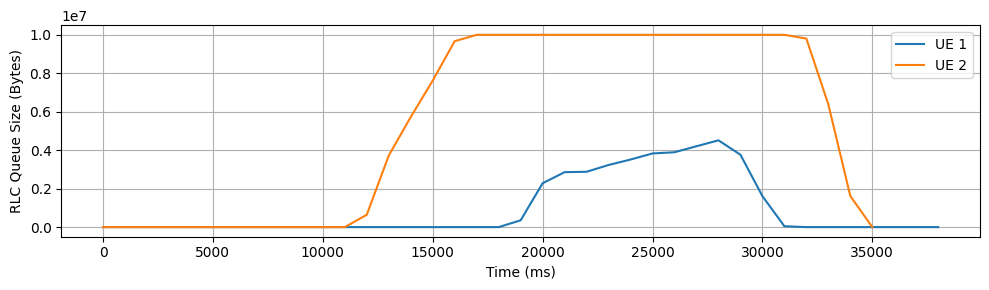

In [67]:
# Pintar cola RLC (sin estabilidad)
plt.figure(figsize=(10, 3))
df = pd.read_csv(file_path)
for uid, group in df.groupby('UID'):    
    unique_times = group.groupby('Time').agg({
        'RLC_Q_Bytes': 'mean'
    }).reset_index()
    if len(unique_times) > 0:
        start_time = unique_times['Time'].iloc[0]
        unique_times['Time_ms'] = (unique_times['Time'] - start_time) * 1000
        plt.plot(unique_times['Time_ms'], unique_times['RLC_Q_Bytes'], label=f'UE {uid+1}')
plt.xlabel('Time (ms)')
plt.ylabel('RLC Queue Size (Bytes)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## RBs

In [64]:
plt.figure(figsize=(10, 3))
df = pd.read_csv(file_path)
if 'RBs' not in df.columns:
    print("Column 'RBs' is not present in the new CSV format. Skipping RBs plot.")
else:
    for uid, group in df.groupby('UID'):
        unique_times = group.groupby('Time').agg({
            'RBs': 'first',
        }).reset_index()
        x = range(len(unique_times))
        plt.plot(x, unique_times['RBs'], marker='o', label=f'UE {uid+1}')
    plt.xlabel('Time (sec.)')
    plt.ylabel('RBs Allocated')
    plt.title('RBs allocated per UE')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Column 'RBs' is not present in the new CSV format. Skipping RBs plot.


In [65]:
df = pd.read_csv(file_path)
if 'RBs' not in df.columns:
    print("Column 'RBs' is not present in the new CSV format. Skipping RBs boxplot.")
else:
    plt.figure(figsize=(8, 3))
    data_to_plot = []
    labels = []
    for uid, group in df.groupby('UID'):
        unique_times = group.groupby('Time').agg({
            'RBs': 'first'
        }).reset_index()
        data_to_plot.append(unique_times['RBs'])
        labels.append(f'UE {uid+1}')
    plt.boxplot(data_to_plot, labels=labels)
    plt.ylabel('RBs')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Column 'RBs' is not present in the new CSV format. Skipping RBs boxplot.


## Coefficients per UE
Visualize the scheduler coefficient (`Coeff_UE`) per UE over time. Values `-1` mean the coefficient was not computed for that UE in that slot.

UE 1: mean coefficient = inf | plotted points = 39
UE 2: mean coefficient = inf | plotted points = 36


<Figure size 1000x300 with 0 Axes>

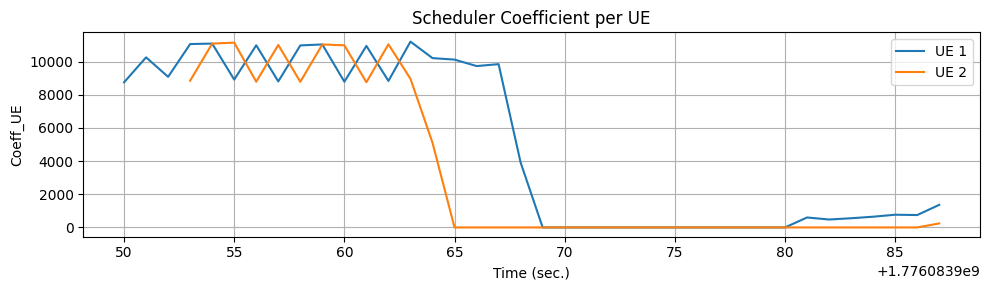

In [66]:
df = pd.read_csv(file_path)

if 'Coeff_UE' not in df.columns:
    raise ValueError("Column 'Coeff_UE' is not present in the CSV.")

# Aggregate once for performance.
coeff_df = (
    df[['Time', 'UID', 'Coeff_UE']]
    .groupby(['UID', 'Time'], as_index=False)['Coeff_UE']
    .mean()
    .sort_values(['UID', 'Time'])
)

# Limit points per UE to keep plotting responsive on large captures.
max_points_per_ue = 2000

fig, ax = plt.subplots(figsize=(10, 3))
for uid, group in coeff_df.groupby('UID', sort=True):
    if len(group) > max_points_per_ue:
        step = max(1, len(group) // max_points_per_ue)
        group_to_plot = group.iloc[::step]
    else:
        group_to_plot = group

    ax.plot(group_to_plot['Time'], group_to_plot['Coeff_UE'], label=f'UE {uid+1}')
    print(f"UE {uid+1}: mean coefficient = {group['Coeff_UE'].mean():.4f} | plotted points = {len(group_to_plot)}")

ax.set_xlabel('Time (sec.)')
ax.set_ylabel('Coeff_UE')
ax.set_title('Scheduler Coefficient per UE')
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()
plt.close(fig)